In [15]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

In [16]:
kb = 1.38e-23 #J/K
e = 1.62e-19 #C
me = 9.1e-31 # kg
h = 6.6e-34 # J s
mp = 1.67e-27 #kg
stefan_boltzman = 5.67e-8 # W/m^2/K^4
c = 3e8 #m/s
a = (4/c)*stefan_boltzman


kb_cgs = 1.38e-16 # cm Dyne/K
e_cgs = 4.8e-10 #cm Dyne^(1/2)

# Relativistic Temperatures of a proton and an electron.

The temperature at which the thermal energy is equal to the rest mass energy $k_b T = m c^2$ can be considered to be the cutoff temperature for when we must treat the system relativistically. This is given for protons and electrons below.

Additionally the number density for a typical ideal gas with an avagadros number of particles at $T = 0 ^\circ C$ and at standard pressure is reported below.

In [17]:
tp = 1.09e13 #K
te = 5.9e9 #K

t0 = 273.15 #K
n0 = 2.7e19 #1/cm^3

# Computing When Coulomb Plasmas can be Encountered

The line that determines whether or not a coulomb plasma may form is given by the variable $\Gamma$ which is defined as follows:

$\Gamma = \frac{(Z e^2)}{a k_b T}$

If a is the distance between particles, then we will have about 1 particle on average for each sphere with radius a. In this way our number density may be taken to be:

$ n = \frac{1}{\frac{4}{3}\pi a^3}$

solving this for a and then plugging into the above equation we can get $\Gamma$ in terms of the number density.

$ \sqrt[3]{\frac{3}{4 \pi n}}= a$

$ \Gamma = \frac{(Z e^2)}{k_b T} \sqrt[3]{\frac{4 \pi n}{3}}$

When Gamma is equal to 1, the conditions may be satisfied for a coulomb plasma.

$ 1 = \frac{(Z e^2)}{k_b T} \sqrt[3]{\frac{4 \pi n}{3}}$

Multiplying both side by T

$ T = \frac{(Z e^2)}{k_b} \sqrt[3]{\frac{4 \pi n}{3}}$

and now we have an expression for the condition for the temperature required for a specific number density of particles to give rise to a coulomb plasma.

In [18]:
def coulomb_plasma(Z,e,kb,n):
    return ((Z*e**2)/kb)*(4*np.pi*n/3)**(1/3)

In [19]:
ncoulomb_log = np.linspace(0,50,100)
ncoulomb = 10**(ncoulomb_log)
gamma1 = coulomb_plasma(1,e_cgs,kb_cgs,ncoulomb)
Tcoulomb_log = np.log10(gamma1)
ncoulomb_log = ncoulomb_log[Tcoulomb_log>0]
Tcoulomb_log = Tcoulomb_log[Tcoulomb_log>0]

# The Quantum Mechanical Treatment

At what point do we need to start considering the effects of Quantum Mechanics. We start with the de Broglie wavelength as a way to see "how quantum mechanical" our system is. 

$\lambda = \frac{h}{p}$

We need to somehow relate this to the temperature and the number density for our plot. To do this we can recognize for an ideal gas 

$E = \frac{3}{2} m v^2 = \frac{3}{2}k_b T $

but we also know:

$p = mv$

so 

$ \frac{3}{2} \frac{p^2}{m} = \frac{3}{2}k_b T $

solving for p

$  p = \sqrt{m k_b T} $

we can now put this into our de Broglie wavelength equation:

$\lambda = \frac{h}{\sqrt{m k_b T}}$

now the question remains what is the appropriate wavelength. A good choice might be when the wavelength is comparable to the particle spacing. At these distances the wavefunctions begin to overlap and there may be some quantum effects we need to consider. If thats the case then the condition we want to check is:

$\lambda = a$

Where $a$ is the distance between particles.

Since a is the distance between particles, we can get to the number density by considering there to be one particle per sphere with radius a:

$ n = \frac{1}{\frac{4}{3}\pi a^3}$

solving this for a and then plugging into the above equation we can get $\lambda$ in terms of the number density.

$ \sqrt[3]{\frac{3}{4 \pi n}}= a$

$\lambda = \sqrt[3]{\frac{3}{4 \pi n}}$

now we can put all of this together and get:

$\sqrt[3]{\frac{3}{4 \pi n}} = \frac{h}{\sqrt{m k_b T}}$

we now must solve for the Temperature:

$T = \frac{h^2}{m k_b} \left(\frac{4 \pi n}{3}\right)^{2/3}$

Using this we can now plot a line on our plot where we expect a quantum mechanical treatment to be necessary.

In [20]:
def quantum_cutoff(n,h,kb,m):
    return h**2/(m*kb)*((4*np.pi*n)/3)**(2/3)

In [21]:
nqm_log = np.linspace(0,50,100)
nqm = 10**(nqm_log)*100**3
Tqm = quantum_cutoff(nqm,h,kb,mp)
Tqm_log = np.log10(Tqm)
nqm_log = nqm_log[Tqm_log>0]
Tqm_log = Tqm_log[Tqm_log>0]

# Cores of Massive Stars

For the cores of massive stars we were asked to plot lines similar to those in:

![Star Cores](images/T_RHO_massive_stars(3).jpeg)

From the plot we can see that the lower line intersects hydrogen with a log density of about 0.75 with a central log T of 7.5.

It ends with a log density of 9.8 and a central log T of 9.9.

The line slightly above the first intersects hydrogen with a log density of 0.5 and a central temperature of 7.55.

It ends with a log density of 9.5 and a central log T of 9.9.

For our plot landscape plot we need the number density rather than the mass density.

We know the molar mass of hydrogen:

$m_H = 1.008 \frac{g}{mol}$

At the line of hydrogen intersection, the mass should be mostly hydrogen. So we can convert it to number density.

$\rho_H = 10^{0.75} \frac{g}{cm^3} = \frac{5.63}{1.008} \frac{mol}{cm^3} = 5.58 * 6.02 * 10^{23} \frac{n}{cm^3} = 3.36 * 10^{24} \frac{n}{cm^3}$

When fusion stops, the core has become all iron. We can use this to estimate the number density.

$m_{Fe} = 55.85 \frac{g}{mol}$

Using this to calculate the number density:

$\rho_{Fe} = 10^{9.8} \frac{g}{cm^3} = \frac{6.3*10^9}{55.85} \frac{mol}{cm^3} = 1.13*10^8 * 6.02 * 10^{23} \frac{n}{cm^3} = 6.8 * 10^{31} \frac{n}{cm^3}$

We can do the same thing for the second star line on the plot:

$\rho_H = 10^{0.5} \frac{g}{cm^3} = \frac{3.16}{1.008} \frac{mol}{cm^3} = 3.14 * 6.02 * 10^{23} \frac{n}{cm^3} = 1.89 * 10^{24} \frac{n}{cm^3}$

$\rho_{Fe} = 10^{9.5} \frac{g}{cm^3} = \frac{3.16*10^9}{55.85} \frac{mol}{cm^3} = 5.66*10^7 * 6.02 * 10^{23} \frac{n}{cm^3} = 3.41 * 10^{31} \frac{n}{cm^3}$

We can now use these values and take their logs to get our plot in terms of the log number density:

| Star | $log(\rho_1)$ | $log(T_1)$ | $log(\rho_2)$ | $log(T_2)$ |
|------|---------------|------------|---------------|------------|
| 15M | 24.5 | 7.5 | 31.8 | 9.9 |
| 25M | 24.3 | 7.55 | 31.5 | 9.9 |

Now we can turn these points into the equation for a line and plot them.

In [22]:
s_corex1 = [24.5,31.8]
s_corey1 = [7.5,9.9]
s_corex2 = [24.3,31.5]
s_corey2 = [7.55, 9.9]

# Galaxy Clusters


From the paper: http://dx.doi.org/10.1088/0004-637X/690/1/367

In the introduction, it is listed that the atomic density is between $10^{-4} \frac{1}{cm^3}$ and $10^{-2} \frac{1}{cm^3}$

The temperatures meanwhile range from $10^{7} K$ and $10^{8} K$

In [23]:
gr_x = [-4,-2,-2,-4,-4]
gr_y = [8,8,7,7,8]

# Photon Entropy

We are given:

$\frac{E}{V} = aT^4$

$dE = TdS$

and asked to plot:

$s = \frac{S}{Nk} = \frac{S}{V} \frac{V}{Nk} = 1$

To calculate the photon entropy, we might recognize that with volume fixed,

$dE = 4aVT^3 dT $

plugging in we get:

$ 4aVT^3 dT = T dS $

Simplifying gives:

$\frac{dS}{dT} = 4aVT^2$

Integrating with respect to $T$:

$S = \int 4aVT^2 dT = \frac{4}{3} a V T^3 + C$

Using the third law of thermodynamics, we can assume at 0K the entropy goes to a minimum which we may pick to be 0.

$0 = \frac{4}{3} a V 0^3 + C \rightarrow C=0$

so 

$S = \frac{4}{3} a V T^3$

In our plot we want the number density vs temperature so we can use the last equation we were given and plug in for $S$:

$\frac{\frac{4}{3} a V T^3}{V} \frac{V}{Nk}  = 1$

Recognizing that $\frac{V}{N} = \frac{1}{\rho}$:

$\frac{4}{3} a T^3 = k\rho \rightarrow T = \sqrt[3]{\frac{3k\rho}{4a}}$

In [24]:
def photon_temp(rho,kb,a):
	return ((3*kb*rho)/(4*a))**(1/3)

In [25]:
nphoton_log = np.linspace(0,50,100)
nphoton = 10**(nphoton_log)*100**3
Tphoton = photon_temp(nphoton,kb,a)
Tphoton_log = np.log10(Tphoton)
nphoton_log = nphoton_log[Tphoton_log>0]
Tphoton_log = Tphoton_log[Tphoton_log>0]

# Plotting

In [26]:
# Generating lines for plots

pts = 100
tps = np.full(pts,np.log10(tp))
tes = np.full(pts,np.log10(te))
xs = np.linspace(0,50,pts)

In [27]:
r_x = [7.5,7.5,25,25,7.5]
r_y =[0,2.5,2.5,0,0]

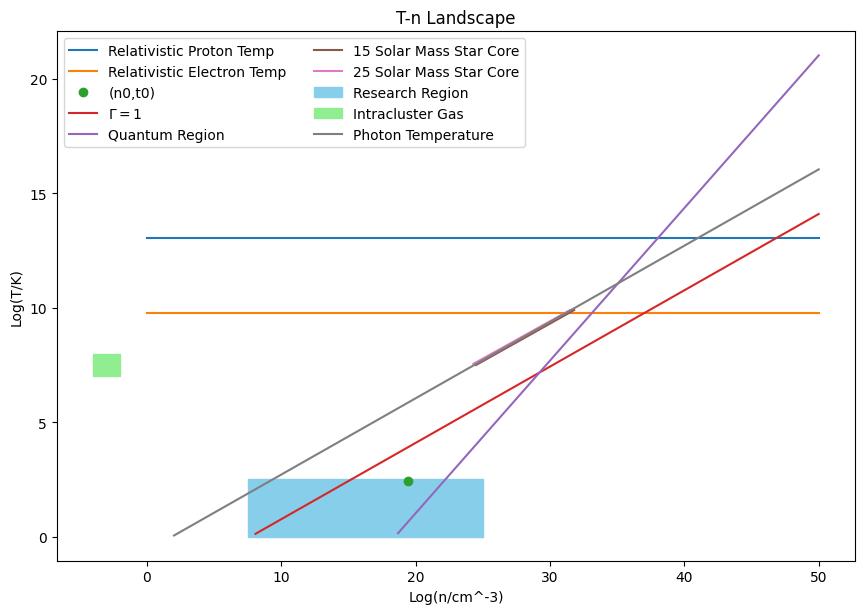

In [32]:
plt.figure(figsize=(35/4, 25/4))  # good for single-column LaTeX

plt.ylabel("Log(T/K)")
plt.xlabel("Log(n/cm^-3)")
plt.title("T-n Landscape")
plt.plot(xs,tps,label="Relativistic Proton Temp")
plt.plot(xs,tes,label="Relativistic Electron Temp")
plt.plot(np.log10(n0),np.log10(t0), 'o', label = "(n0,t0)")
plt.plot(ncoulomb_log,Tcoulomb_log,label=r"$\Gamma=1$")
plt.plot(nqm_log,Tqm_log,label="Quantum Region")
plt.plot(s_corex1,s_corey1, label="15 Solar Mass Star Core")
plt.plot(s_corex2,s_corey2, label="25 Solar Mass Star Core")
plt.fill(r_x,r_y,color="skyblue",label="Research Region")
plt.fill(gr_x,gr_y,color="lightgreen",label="Intracluster Gas")
plt.plot(nphoton_log,Tphoton_log, label="Photon Temperature")
plt.legend(ncol=2)

plt.tight_layout()
plt.savefig('landscape_plot.pdf', dpi=300)